# load liabraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\HP\anaconda3\anaconda1\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\anaconda1\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
import warnings
warnings.filterwarnings('ignore')

### load datasets


In [3]:
books = pd.read_csv("Books.csv", encoding="latin-1", low_memory=False)
ratings = pd.read_csv("Ratings.csv",encoding="latin-1", low_memory=False)
users = pd.read_csv("Users.csv",encoding="latin-1", low_memory=False)

In [4]:
books.head()


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [6]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [7]:
print(books.describe())
print('--------------------------------------------')
print(ratings.describe())
print('--------------------------------------------')
print(users.describe())
print('--------------------------------------------')

              ISBN      Book-Title      Book-Author Year-Of-Publication  \
count       271360          271360           271358              271360   
unique      271360          242135           102022                 118   
top     0195153448  Selected Poems  Agatha Christie                2002   
freq             1              27              632               17627   

        Publisher                                        Image-URL-S  \
count      271358                                             271360   
unique      16807                                             271044   
top     Harlequin  http://images.amazon.com/images/P/042511774X.0...   
freq         7535                                                  2   

                                              Image-URL-M  \
count                                              271360   
unique                                             271044   
top     http://images.amazon.com/images/P/042511774X.0...   
freq               

####  data overview

In [8]:
print("books shape: ",books.shape)
print("users shape: ",users.shape)
print("ratings shape: ",ratings.shape)

books shape:  (271360, 8)
users shape:  (278858, 3)
ratings shape:  (1149780, 3)


In [9]:
print("Book info:")
print(books.info())
print('-----------------------------------------------')
print("User info:")
print(users.info())
print('-----------------------------------------------')
print("rating info:")
print(ratings.info())
print('-----------------------------------------------')

Book info:
<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ISBN                 271360 non-null  str  
 1   Book-Title           271360 non-null  str  
 2   Book-Author          271358 non-null  str  
 3   Year-Of-Publication  271360 non-null  str  
 4   Publisher            271358 non-null  str  
 5   Image-URL-S          271360 non-null  str  
 6   Image-URL-M          271360 non-null  str  
 7   Image-URL-L          271357 non-null  str  
dtypes: str(8)
memory usage: 84.4 MB
None
-----------------------------------------------
User info:
<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64


 #### missing values

In [10]:
print("Books:")
print(books.isnull().sum())
print("-----------------------------------------")
print("user:")
print(users.isnull().sum())
print("-----------------------------------------")
print("rating:")
print(ratings.isnull().sum())
print("-----------------------------------------")

Books:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64
-----------------------------------------
user:
User-ID          0
Location         0
Age         110762
dtype: int64
-----------------------------------------
rating:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64
-----------------------------------------


#### handling missing values

In [11]:
books_text = books.select_dtypes(include='object').columns
books_numeric = books.select_dtypes(include='number').columns

books[books_text] = books[books_text].fillna(
    books[books_text].mode().iloc[0]
)
books[books_numeric] = books[books_numeric].fillna(
    books[books_numeric].median()
)

In [12]:
users_text = users.select_dtypes(include='object').columns
users_numeric = users.select_dtypes(include='number').columns

users[users_text] = users[users_text].fillna(
    users[users_text].mode().iloc[0]
)
users[users_numeric] = users[users_numeric].fillna(
    users[users_numeric].median()
)


In [13]:
ratings_text = ratings.select_dtypes(include='object').columns
ratings_numeric = ratings.select_dtypes(include='number').columns

ratings[ratings_text] = ratings[ratings_text].fillna(
    ratings[ratings_text].mode().iloc[0]
)
ratings[ratings_numeric] = ratings[ratings_numeric].fillna(
    ratings[ratings_numeric].median()
)

In [14]:
print("Books:")
print(books.isnull().sum())
print("-----------------------------------------")
print("user:")
print(users.isnull().sum())
print("-----------------------------------------")
print("rating:")
print(ratings.isnull().sum())
print("-----------------------------------------")

Books:
ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64
-----------------------------------------
user:
User-ID     0
Location    0
Age         0
dtype: int64
-----------------------------------------
rating:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64
-----------------------------------------


#### data cleaning

In [15]:
books.drop_duplicates(inplace=True)
users.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)

In [16]:
users = users[
    (users['Age'] >= 5) &
    (users['Age'] <= 90)
]




# FEATURE ENGINEERING

In [17]:
users['Country']=users['Location'].astype(str).apply(
    lambda x:x.split(",")[-1].strip()
)

In [18]:
users['Age_group']=pd.cut(
    users['Age'],
    bins=[0,18,30,45,60,100],
    labels=[
        'Teen',
        'Young Adult',
        'Adult',
        'Middle Age',
        'Senior'
    ]
)

In [19]:
books['Year-Of-Publication']=pd.to_numeric(books['Year-Of-Publication'],errors='coerce')

books['Book_Age']=2026-books['Year-Of-Publication']

In [20]:
books = books[
    (books['Year-Of-Publication'] >= 1900) &
    (books['Year-Of-Publication'] <= 2026)
]

In [21]:
author_count = books[
    'Book-Author'
].value_counts()

In [22]:
books['Author_Popularity'] = books[
    'Book-Author'
].map(author_count)

In [23]:
publisher_count = books[
    'Publisher'
].value_counts()

In [24]:
books['Publisher_Popularity'] = books[
    'Publisher'
].map(publisher_count)

####  Merge Data 

In [25]:


final_dataset = ratings.merge(
    books,
    on='ISBN'
)

final_dataset = final_dataset.merge(
    users,
    on='User-ID'
)

print(final_dataset.shape)

(1012228, 17)


### data Visualization

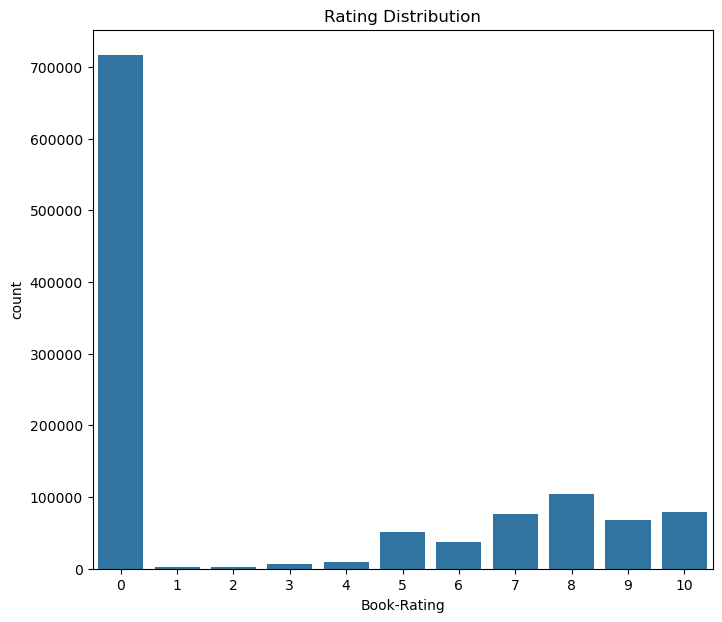

In [26]:
plt.figure(figsize=(8,7))
sns.countplot(x='Book-Rating',data=ratings)
plt.title("Rating Distribution")
plt.show()

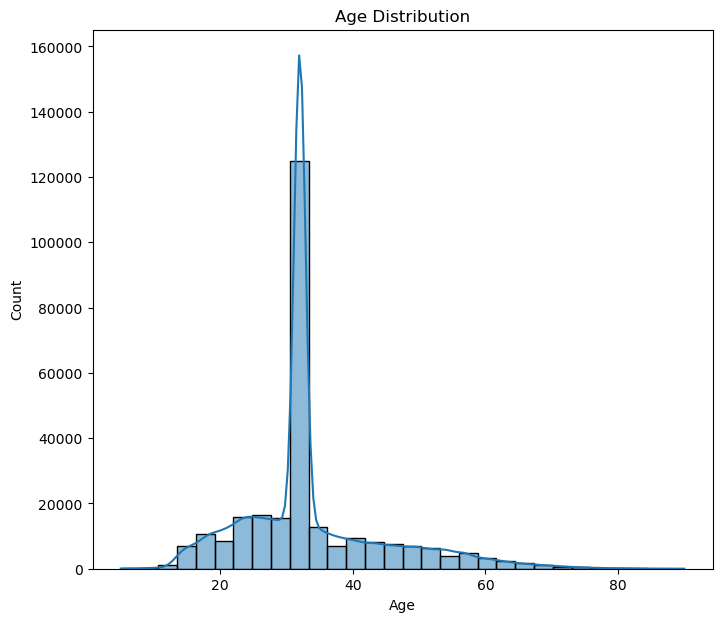

In [27]:
plt.figure(figsize=(8,7))
sns.histplot(users['Age'],bins=30,kde=True)
plt.title('Age Distribution')
plt.show()

In [28]:
top_author=books['Book-Author'].value_counts().head(10)

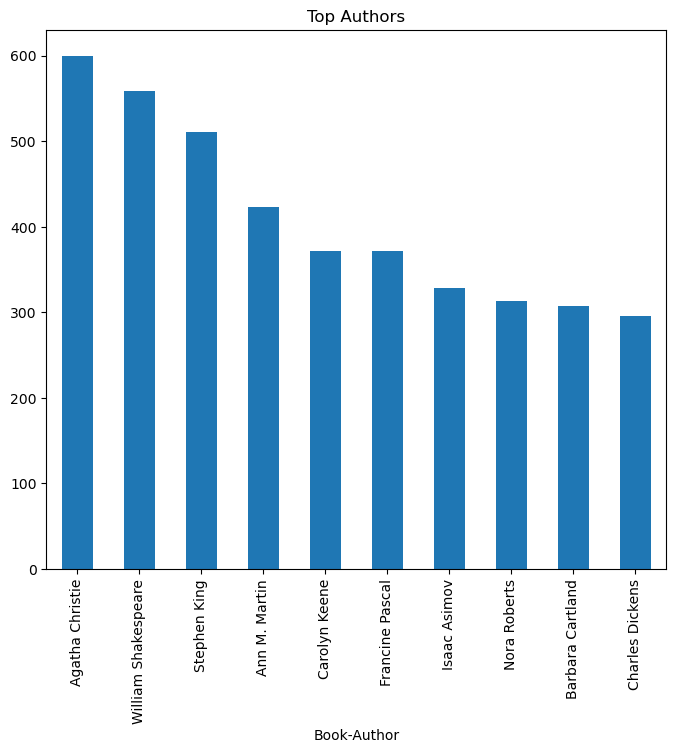

In [29]:
plt.figure(figsize=(8,7))
top_author.plot(kind='bar')
plt.title("Top Authors")
plt.show()

In [30]:
top_publisher=books['Publisher'].value_counts().head(10)

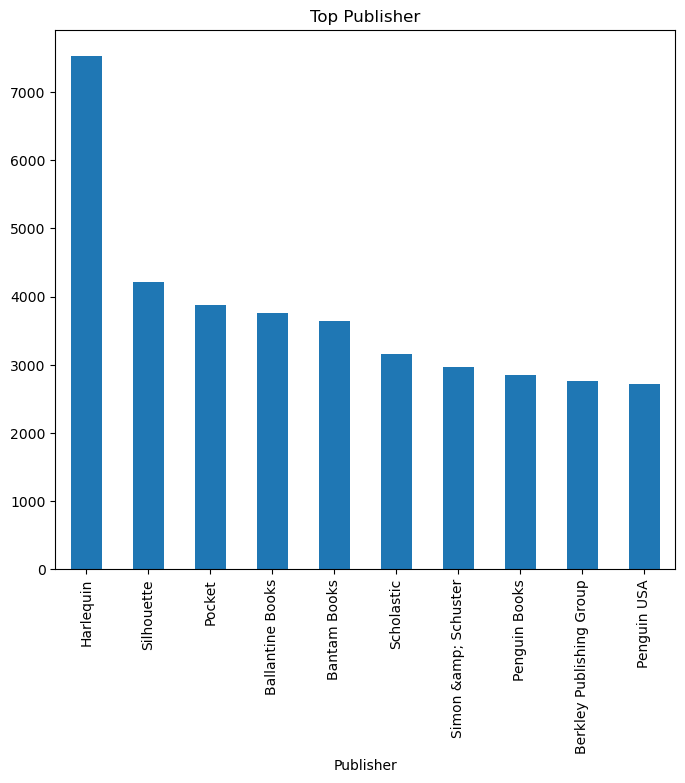

In [31]:
plt.figure(figsize=(8,7))
top_publisher.plot(kind='bar')
plt.title("Top Publisher")
plt.show()

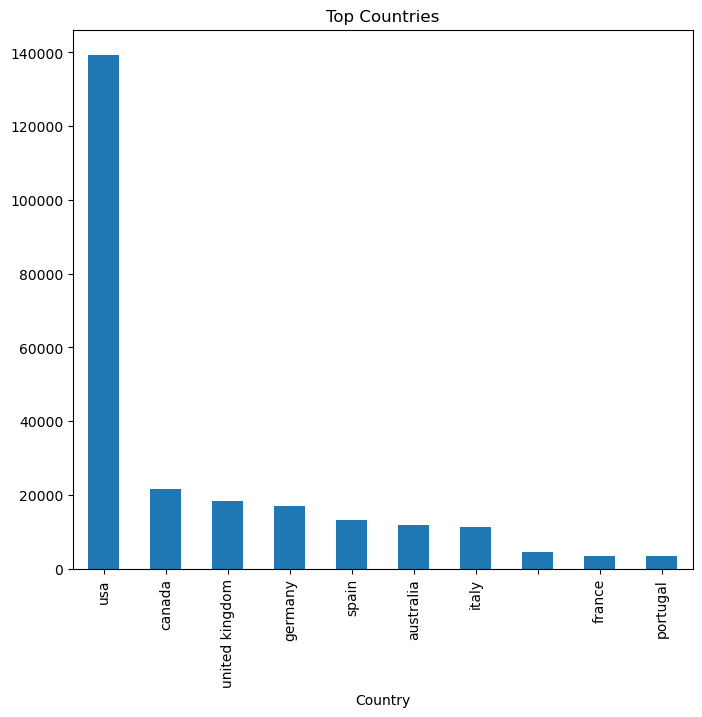

In [32]:
plt.figure(figsize=(8,7))
users['Country']\
    .value_counts()\
    .head(10)\
    .plot(kind='bar')
plt.title('Top Countries')
plt.show()

In [33]:
top_books=ratings.groupby('ISBN')['Book-Rating'] \
    .count() \
    .sort_values(ascending=False) \
    .head(10)


In [34]:
print("\n Top Rated Books:")
print(top_books)


 Top Rated Books:
ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
044023722X     647
0679781587     639
0142001740     615
067976402X     614
0671027360     586
Name: Book-Rating, dtype: int64


### Outlier Detection

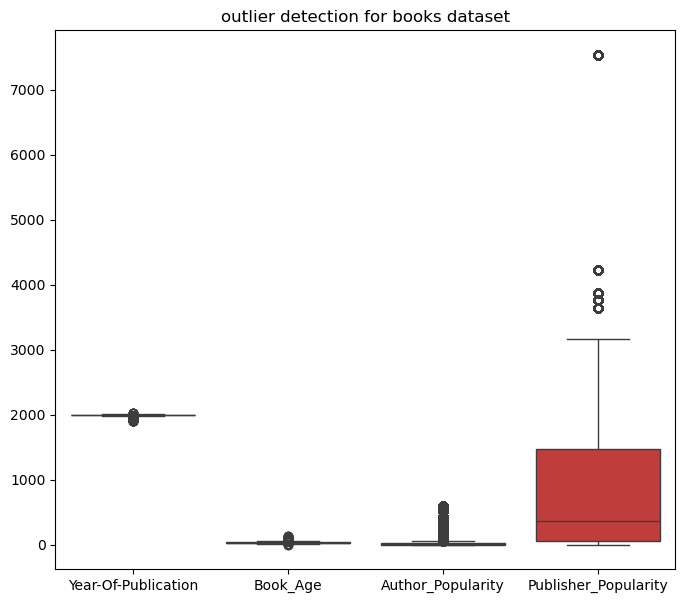

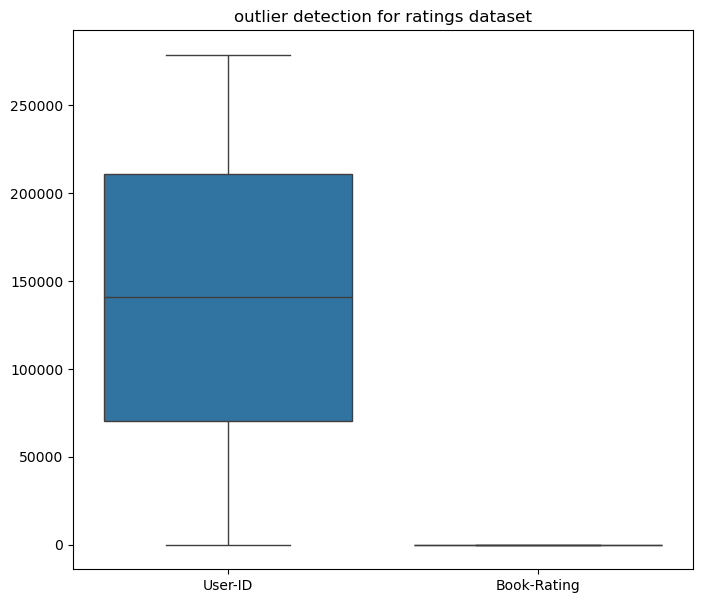

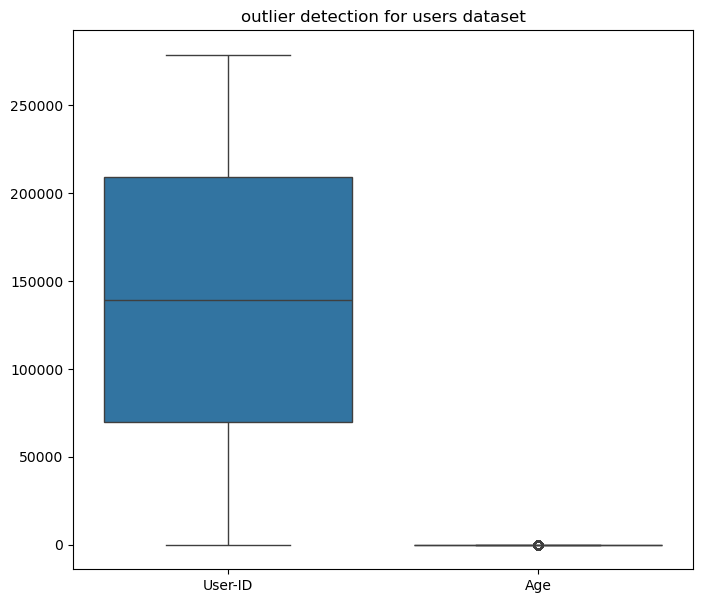

In [35]:
plt.figure(figsize=(8,7))
sns.boxplot(books)
plt.title("outlier detection for books dataset")
plt.show()

plt.figure(figsize=(8,7))
sns.boxplot(ratings)
plt.title("outlier detection for ratings dataset")
plt.show()

plt.figure(figsize=(8,7))
sns.boxplot(users)
plt.title("outlier detection for users dataset")
plt.show()

In [36]:
books_text = books.select_dtypes(include='object').columns
books_numeric = books.select_dtypes(include='number').columns
books_q1=books[books_numeric].quantile(0.25)
books_q3=books[books_numeric].quantile(0.75)

users_text = users.select_dtypes(include='object').columns
users_numeric = users.select_dtypes(include='number').columns
users_q1=users[users_numeric].quantile(0.25)
users_q3=users[users_numeric].quantile(0.75)

ratings_text = ratings.select_dtypes(include='object').columns
ratings_numeric = ratings.select_dtypes(include='number').columns
ratings_q1=ratings[ratings_numeric].quantile(0.25)
ratings_q3=ratings[ratings_numeric].quantile(0.75)

In [37]:
books_IQR=books_q3-books_q1
users_IQR=users_q3-users_q1
ratings_IQR=ratings_q3-ratings_q1

In [38]:
books_lower_bound=books_q1-1.5*books_IQR
books_upper_bound=books_q3+1.5*books_IQR

users_lower_bound=users_q1-1.5*users_IQR
users_upper_bound=users_q3+1.5*users_IQR

ratings_lower_bound=ratings_q1-1.5*ratings_IQR
ratings_upper_bound=ratings_q3+1.5*ratings_IQR

In [39]:
datasets = [
    (books, books_numeric, books_lower_bound, books_upper_bound),
    (users, users_numeric, users_lower_bound, users_upper_bound),
    (ratings, ratings_numeric, ratings_lower_bound, ratings_upper_bound)
]

for df, cols, lower_bound, upper_bound in datasets:
    for col in cols:
        df[col] = df[col].clip(
            lower=lower_bound[col],
            upper=upper_bound[col]
        )

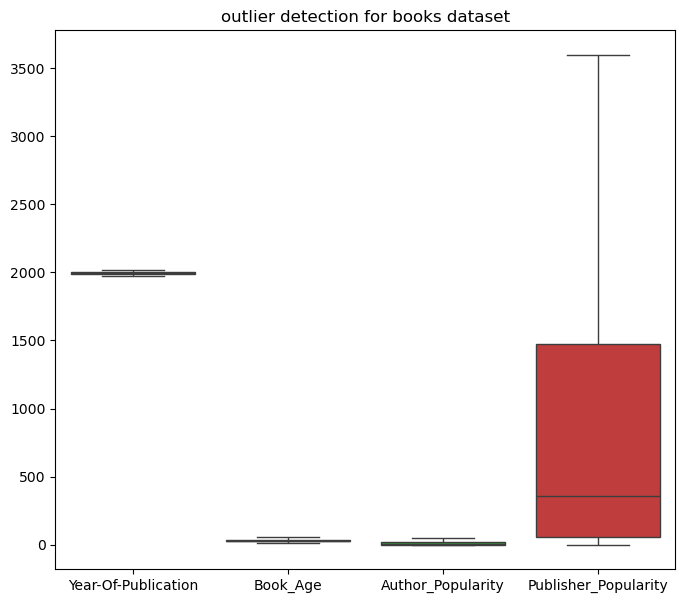

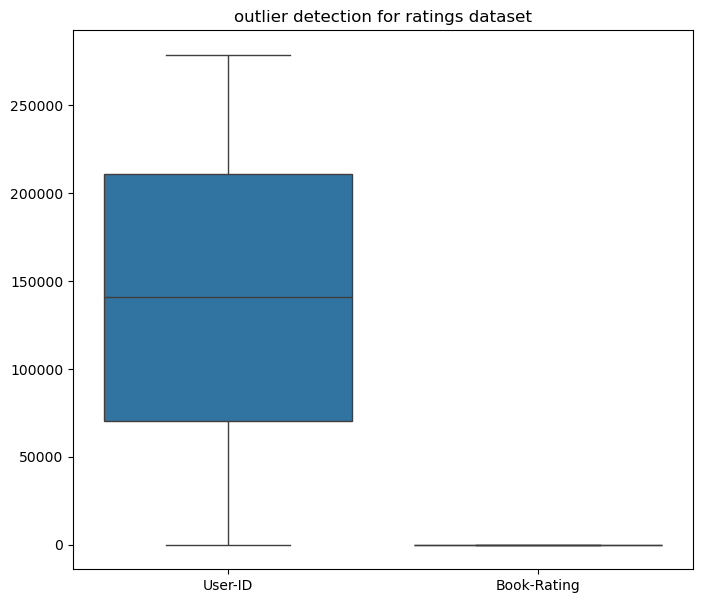

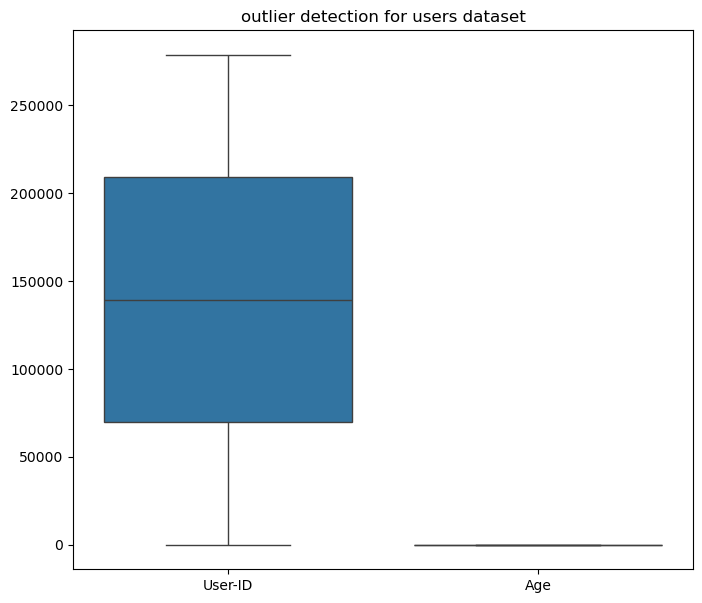

In [40]:
plt.figure(figsize=(8,7))
sns.boxplot(books)
plt.title("outlier detection for books dataset")
plt.show()

plt.figure(figsize=(8,7))
sns.boxplot(ratings)
plt.title("outlier detection for ratings dataset")
plt.show()

plt.figure(figsize=(8,7))
sns.boxplot(users)
plt.title("outlier detection for users dataset")
plt.show()

#### save cleaned file

In [41]:
final_dataset.to_csv('final_dataset.csv', index=False)

# Model Biuilding

In [42]:
import pandas as pd
import numpy as np
import pickle

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [43]:
final_dataset=pd.read_csv('final_dataset.csv')
books=pd.read_csv('Books.csv',low_memory=False,encoding="latin-1")

#### Model 1:-Popularity Based

In [44]:
popular_df=final_dataset.groupby(
        'Book-Title'
).agg(
    avg_rating=('Book-Rating','mean'),
    num_rating=('Book-Rating','count')
)

In [45]:
popular_df=popular_df[popular_df['num_rating']>=50]

In [46]:
popular_df=popular_df.sort_values('avg_rating',ascending=False)


In [47]:
print("\nTop 10 Popular Books")
print(popular_df.head(10))


Top 10 Popular Books
                                                    avg_rating  num_rating
Book-Title                                                                
Free                                                  8.017857          56
The Stand (The Complete and Uncut Edition)            6.175439          57
Griffin &amp; Sabine: An Extraordinary Correspo...    6.041667          72
Harry Potter and the Prisoner of Azkaban (Book 3)     5.828235         425
Harry Potter and the Goblet of Fire (Book 4)          5.798956         383
The Little Prince                                     5.785714         140
The Cat in the Hat                                    5.754717          53
Harry Potter and the Sorcerer's Stone (Book 1)        5.737410         278
The Hobbit                                            5.700000          80
Harry Potter and the Order of the Phoenix (Book 5)    5.511628         344


In [48]:
def popularity_recommend(top_n=10):
    return popular_df.head(top_n)

print("\nPopularity Based Recommendations")
print(popularity_recommend())

total_books = final_dataset['Book-Title'].nunique()

recommended_books = len(popular_df)

coverage = round(
    (recommended_books / total_books) * 100,
    2
)


Popularity Based Recommendations
                                                    avg_rating  num_rating
Book-Title                                                                
Free                                                  8.017857          56
The Stand (The Complete and Uncut Edition)            6.175439          57
Griffin &amp; Sabine: An Extraordinary Correspo...    6.041667          72
Harry Potter and the Prisoner of Azkaban (Book 3)     5.828235         425
Harry Potter and the Goblet of Fire (Book 4)          5.798956         383
The Little Prince                                     5.785714         140
The Cat in the Hat                                    5.754717          53
Harry Potter and the Sorcerer's Stone (Book 1)        5.737410         278
The Hobbit                                            5.700000          80
Harry Potter and the Order of the Phoenix (Book 5)    5.511628         344


#### Model 2:-Collaborative Filtering

In [49]:
active_users=final_dataset.groupby('User-ID')['Book-Rating'].count()

In [50]:
active_users=active_users[active_users>=100].index

In [51]:
filtered=final_dataset[final_dataset['User-ID'].isin(active_users)]

In [52]:
popular_books=filtered.groupby('Book-Title')['Book-Rating'].count()

In [53]:
popular_books=popular_books[popular_books>=50].index

In [54]:
filtered=filtered[filtered['Book-Title'].isin(popular_books)]

In [55]:
pt=filtered.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')


In [56]:
pt.fillna(0,inplace=True)

User-ID,254,507,882,1424,1435,1733,1903,2033,2110,2276,...,275020,275970,276463,276680,277427,277478,277639,278137,278188,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010: Odyssey Two,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
204 Rosewood Lane,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24 Hours,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
similarity_scores=cosine_similarity(pt)

In [58]:
def collaborative_recommend(book_name):

    index = np.where(pt.index == book_name)[0][0]

    similar_items = sorted(
        list(enumerate(similarity_scores[index])),
        key=lambda x: x[1],
        reverse=True
    )[1:6]

    recommendations = []

    for item in similar_items:
        recommendations.append(
            pt.index[item[0]]
        )

    return recommendations

#### Model 3:Content Based

In [59]:
book_rating_count = ratings.groupby('ISBN')['Book-Rating'].count()

popular_isbn = book_rating_count[
    book_rating_count >= 50
].index

books_filtered = books[
    books['ISBN'].isin(popular_isbn)
]

print(books_filtered.shape)

(2161, 8)


In [60]:
books = books.drop_duplicates(
    subset='Book-Title'
).reset_index(drop=True)

In [61]:
books_filtered['Features'] = (
    books_filtered['Book-Author'].fillna('') +
    ' ' +
    books_filtered['Publisher'].fillna('')
)

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(
    books_filtered['Features']
)

In [62]:
content_similarity = cosine_similarity(
    tfidf_matrix
)


In [63]:
indices=pd.Series(books.index,index=books['Book-Title']).drop_duplicates()

In [64]:
def content_recommend(book_name):

    try:
        print("Searching for:", book_name)
        idx = indices[book_name]
        print("Index Found:", idx)

        sim_score = list(enumerate(content_similarity[idx]))

        sim_score = sorted(
            sim_score,
            key=lambda x: x[1],
            reverse=True
        )[1:6]

        book_indices = [
            i[0]
            for i in sim_score
        ]

        return list(books['Book-Title'].iloc[book_indices])

    except Exception as e:
        print("ERROR:", e)
        return ["Book Not Found"]

#### Model 4:- Hybrid

In [65]:
def hybrid_recommend(book_name):

    collab = collaborative_recommend(book_name)

    try:
        content = content_recommend(book_name)
        content = list(content)
    except:
        content = []

    final = list(
        dict.fromkeys(
            collab + content
        )
    )

    return final[:10]

#### Evaluation


In [66]:
total_books = final_dataset['Book-Title'].nunique()

popularity_coverage = round(
    (len(popular_df) / total_books) * 100,
    2
)

collaborative_coverage = round(
    (len(pt.index) / total_books) * 100,
    2
)

content_coverage = 100.0
hybrid_coverage = 100.0

In [67]:
print("\n Model Evaluation:-")
print("Total Books:- ",pt.shape[0])
print('-------------------------------------------')
print("Total Users:- ",pt.shape[1])
print('-------------------------------------------')
coverage=(len(pt.index)/
         final_dataset['Book-Title'].nunique())*100
print("coverage:- ",round(coverage,2),"%")
print('-------------------------------------------')
print("\nPopularity Model Evaluation")
print("Total Books :", total_books)
print("Recommended Books :", recommended_books)
print("Coverage :", coverage, "%")



 Model Evaluation:-
Total Books:-  1054
-------------------------------------------
Total Users:-  1614
-------------------------------------------
coverage:-  0.45 %
-------------------------------------------

Popularity Model Evaluation
Total Books : 236836
Recommended Books : 2393
Coverage : 0.445033694201895 %


#### Model Comparison Table

In [68]:
evaluation_df = pd.DataFrame({
    'Model':[
        'Popularity Based',
        'Collaborative Filtering',
        'Content Based',
        'Hybrid'
    ],
    'Coverage (%)':[
        popularity_coverage,
        collaborative_coverage,
        content_coverage,
        hybrid_coverage
    ],
    'Personalization':[
        'Low',
        'High',
        'Medium',
        'High'
    ]
})

print(evaluation_df)

                     Model  Coverage (%) Personalization
0         Popularity Based          1.01             Low
1  Collaborative Filtering          0.45            High
2            Content Based        100.00          Medium
3                   Hybrid        100.00            High


#### Testing

In [69]:
sample_book=pt.index[1]
print("\n Input Book:- ")
print(sample_book)
print('-------------------------------------------')
print("\nCollaborative Recommendations:- ")
print(collaborative_recommend(sample_book))
print('-------------------------------------------')
print("\ncontent Recommendations:- ")
print(content_recommend(sample_book))
print('-------------------------------------------')
print("\nHybrid Recommendations:- ")
print(hybrid_recommend(sample_book))
print('-------------------------------------------')



 Input Book:- 
1st to Die: A Novel
-------------------------------------------

Collaborative Recommendations:- 
['Along Came a Spider (Alex Cross Novels)', 'Pop Goes the Weasel', 'Roses Are Red (Alex Cross Novels)', '2nd Chance', 'The Summons']
-------------------------------------------

content Recommendations:- 
Searching for: 1st to Die: A Novel
Index Found: 1818
['1st to Die: A Novel', 'The Word \\Desire\\""', 'Mustang Man (Western Lovers, 4)', "Sparks of Genius: The Thirteen Thinking Tools of the World's Most Creative People", "The Cat Who Wasn't There"]
-------------------------------------------

Hybrid Recommendations:- 
Searching for: 1st to Die: A Novel
Index Found: 1818
['Along Came a Spider (Alex Cross Novels)', 'Pop Goes the Weasel', 'Roses Are Red (Alex Cross Novels)', '2nd Chance', 'The Summons', '1st to Die: A Novel', 'The Word \\Desire\\""', 'Mustang Man (Western Lovers, 4)', "Sparks of Genius: The Thirteen Thinking Tools of the World's Most Creative People", "The C

#### Save Model


In [70]:
pickle.dump(
    popular_df,
    open('popular.pkl','wb')
)

pickle.dump(
    pt,
    open('pivot.pkl','wb')
)

pickle.dump(
    similarity_scores,
    open('similarity.pkl','wb')
    )

pickle.dump(
    books,
    open('books.pkl','wb')
)

pickle.dump(
    content_similarity,
    open('content_similarity.pkl','wb')

)
print("\nModels Saved Successfully")


Models Saved Successfully


In [71]:
books_small = books[
    ['Book-Title','Book-Author','Image-URL-M']
].drop_duplicates()

books_small.to_pickle('books_small.pkl')

In [72]:
books = pickle.load(open('books_small.pkl','rb'))

In [73]:
recommended_books = books[
    books['Book-Title'].isin(pt.index)
]

recommended_books.to_pickle('books_small.pkl')

In [74]:
import os

print(os.path.getsize('books.pkl')/(1024*1024))

75.79694652557373


NameError: name 'st' is not defined